In [41]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
import time
from IPython.display import display, clear_output   #jupyter animation

import os
os.makedirs("snapshots_data", exist_ok=True)

In [42]:
def save_checkpoint(filepath, lattice, steps, energy, E_current):
    np.savez(
        filepath, 
        lattice=lattice, 
        history_steps=steps, 
        history_energy=energy, 
        E_current=E_current
    )
    print(f"[!] Checkpoint saved to '{filepath}'")

def load_checkpoint(filepath):
    data = np.load(filepath)
    lattice = data['lattice']
    history_steps = list(data['history_steps'])
    history_energy = list(data['history_energy'])
    E_current = float(data['E_current'])
    print(f"[!] Loaded checkpoint from '{filepath}' at step {history_steps[-1]}")
    return lattice, history_steps, history_energy, E_current

In [43]:
# --- 1. Configuration & Toggles ---
RESTART = True  # Set to True to resume from a saved checkpoint
checkpoint_file = "simulation_checkpoint.npz"

L = 16  
num_species = 4
total_atoms = L * L  
temperature = 0.5  
steps_to_add = 50000  # How many steps to run in this session
window_size = 500

In [44]:
# A symmetric 4x4 energy lookup matrix
energy_matrix = np.array([
    [ 0.0, -2.0,  0.5,  0.1],  # Interactions for Atom 0
    [-2.0,  0.0,  0.2,  0.8],  # Interactions for Atom 1
    [ 0.5,  0.2,  0.0,  1.5],  # Interactions for Atom 2
    [ 0.1,  0.8,  1.5,  0.0]   # Interactions for Atom 3
])

In [45]:
def calculate_total_energy(lattice, energy_matrix):
    """
    Calculates total energy where every atom pair configuration 
    has a specific energy defined in energy_matrix.
    """
    # Grab the right and down neighbors using our periodic wrapping
    right_neighbors = np.roll(lattice, shift=-1, axis=1)
    down_neighbors = np.roll(lattice, shift=-1, axis=0)
    
    # Advanced NumPy indexing:
    # energy_matrix[lattice, right_neighbors] creates a 2D array of the same shape
    # as our lattice, where each pixel contains the exact pair energy value.
    bonds_right = energy_matrix[lattice, right_neighbors]
    bonds_down = energy_matrix[lattice, down_neighbors]
    
    # Sum up all the mapped energies
    total_energy = np.sum(bonds_right) + np.sum(bonds_down)
    return float(total_energy)

Initialize or Resume

In [46]:
# --- 2. Initialize or Resume ---
if RESTART and os.path.exists(checkpoint_file):
    # Load past run state
    lattice, history_steps, history_energy, E_current = load_checkpoint(checkpoint_file)
    start_step = history_steps[-1] + 1
    end_step = start_step + steps_to_add
else:
    # Start a brand new simulation
    print("[!] Starting a fresh simulation...")
    atoms_flat = np.repeat(np.arange(num_species), total_atoms // num_species)
    np.random.shuffle(atoms_flat)
    lattice = atoms_flat.reshape((L, L))
    
    history_steps = []
    history_energy = []
    E_current = calculate_total_energy(lattice, energy_matrix)
    start_step = 0
    end_step = steps_to_add

[!] Loaded checkpoint from 'simulation_checkpoint.npz' at step 649999


4. Metropolis step (swap neighbors and accept or reject based on canonical Metropolis)

In [47]:
DIRECTIONS = np.array([
    [-1,  0],  # Up
    [ 1,  0],  # Down
    [ 0, -1],  # Left
    [ 0,  1]   # Right
])

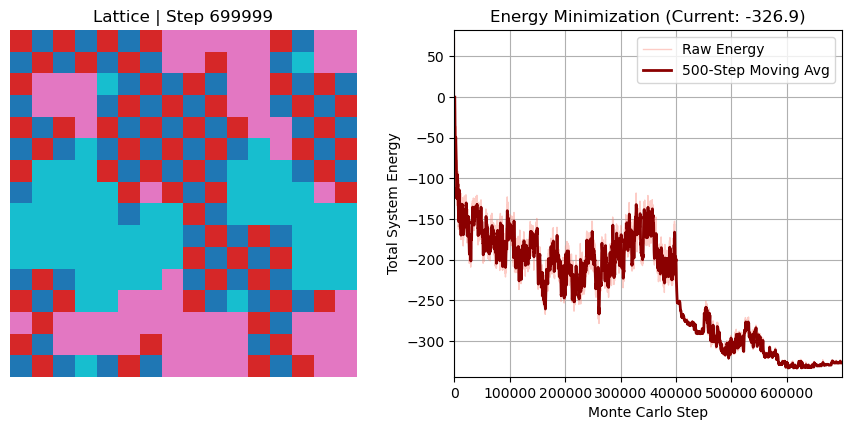

[!] Checkpoint saved to 'simulation_checkpoint.npz'


In [48]:
# --- 3. Set Up Figure ---
fig, (ax_grid, ax_energy) = plt.subplots(1, 2, figsize=(11, 4.5))
cmap_clean = plt.colormaps['tab10'].resampled(num_species)

im = ax_grid.imshow(lattice, cmap=cmap_clean, vmin=0, vmax=num_species-1)
ax_grid.axis('off')

line_raw, = ax_energy.plot(history_steps, history_energy, color='salmon', alpha=0.4, label='Raw Energy', lw=1)
line_ma, = ax_energy.plot([], [], color='darkred', label=f'{window_size}-Step Moving Avg', lw=2)
ax_energy.set_xlabel("Monte Carlo Step")
ax_energy.set_ylabel("Total System Energy")
ax_energy.grid(True)
ax_energy.legend(loc='upper right')

# --- 4. Loop from start_step to end_step ---
for step in range(start_step, end_step):
    coord_1 = np.random.randint(0, L, size=2)
    shift = DIRECTIONS[np.random.randint(0, 4)]
    coord_2 = (coord_1 + shift) % L
    
    i1, j1 = coord_1
    i2, j2 = coord_2
    
    # Propose swap
    lattice[i1, j1], lattice[i2, j2] = lattice[i2, j2], lattice[i1, j1]
    E_proposed = calculate_total_energy(lattice, energy_matrix)
    dE = E_proposed - E_current
    
    if dE <= 0 or np.random.rand() < np.exp(-dE / temperature):
        E_current = E_proposed
    else:
        lattice[i1, j1], lattice[i2, j2] = lattice[i2, j2], lattice[i1, j1]
        
    history_steps.append(step)
    history_energy.append(E_current)
        
    if step % 2000 == 0 or step == end_step - 1:
        np.save(f"snapshots_data/lattice_step_{step:04d}.npy", lattice)
    
    if step % 500 == 0 or step == end_step - 1:
        im.set_data(lattice)
        ax_grid.set_title(f"Lattice | Step {step}")
        
        if len(history_energy) >= window_size:
            weights = np.ones(window_size) / window_size
            ma_values = np.convolve(history_energy, weights, mode='valid')
            ma_steps = history_steps[window_size - 1:]
            line_ma.set_data(ma_steps, ma_values)
        
        line_raw.set_data(history_steps, history_energy)
        ax_energy.set_xlim(0, max(10, step))
        ax_energy.set_ylim(min(history_energy) - 10, max(history_energy) + 10)
        ax_energy.set_title(f"Energy Minimization (Current: {E_current:.1f})")
        
        display(fig, clear=True)
        time.sleep(0.0001)

# --- 5. Save Progress at Termination ---
save_checkpoint(checkpoint_file, lattice, history_steps, history_energy, E_current)
plt.close(fig)